#Revenue and Correlation Analysis.
The purpose of the following code is to analyse the overall revenue between July 2023 and July 2025 as well as find out if there is a correlation between Price of an item and the units sold. In order to complete the analysis, the data set needs to be cleaned from all outliers, typos, and similar entries that might skew the analysis. Afterwards, the statistical analysis will be made and the results will be visualised for better understanding. The code comprises of 3 sections: Loading, Cleaning, and Analysis & Visualisation.

##1. Loading the data
The data set is to be loaded for further analysis

In [ ]:
#importing the necessary libraries
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

uploadedFile = files.upload()
fileName = list(uploadedFile.keys())[0]
df = pd.read_csv(fileName)

Saving nigeria_messy_sales_dataset.csv to nigeria_messy_sales_dataset.csv


In [ ]:
#Intital look at the data to get basic understanding and check if it was loaded properly
df.head()

,Customer Name,State,Product,Units Sold,Unit Price,Total Sale,Sale Date,Sales Channel,Order ID
0,NaN,rivers,KEYBOARD,NaN,NaN,NaN,2025-04-27,Online,NaN
1,Allison Hill,Lagos,Headphones,NaN,267992.94,NaN,2024-03-15,Wholesale,4c636e95-025f-4543-8997-623ae0723d96
2,Noah Rhodes,Anambra,Keyboard,NaN,42364.41,NaN,2024-12-10,NaN,edaf3766-1b78-4ede-9a4f-fc0c9165f2ed
3,Angie Henderson,Delta,Keyboard,NaN,279444.94,NaN,2024-04-05,NaN,74503887-48d9-4846-95c5-51fcfba57cc8
4,Daniel Wagner,Delta,Tablet,NaN,95899.74,NaN,2025-01-12,NaN,8639bd41-8b15-4d94-a42d-0cd7fd359f6a


##2. Cleaning
The data is cleaned from outliers, typos, the format in each column is standardised, and missing values are handles.

###2.1 Inspection

In [ ]:
#Shape - how many rows and columns the set has
print(df.shape)

#Column names and data types
print(df.dtypes)

#First 5 rows
df.head()

(550, 9)
Customer Name     object
State             object
Product           object
Units Sold       float64
Unit Price       float64
Total Sale       float64
Sale Date         object
Sales Channel     object
Order ID          object
dtype: object


,Customer Name,State,Product,Units Sold,Unit Price,Total Sale,Sale Date,Sales Channel,Order ID
0,NaN,rivers,KEYBOARD,NaN,NaN,NaN,2025-04-27,Online,NaN
1,Allison Hill,Lagos,Headphones,NaN,267992.94,NaN,2024-03-15,Wholesale,4c636e95-025f-4543-8997-623ae0723d96
2,Noah Rhodes,Anambra,Keyboard,NaN,42364.41,NaN,2024-12-10,NaN,edaf3766-1b78-4ede-9a4f-fc0c9165f2ed
3,Angie Henderson,Delta,Keyboard,NaN,279444.94,NaN,2024-04-05,NaN,74503887-48d9-4846-95c5-51fcfba57cc8
4,Daniel Wagner,Delta,Tablet,NaN,95899.74,NaN,2025-01-12,NaN,8639bd41-8b15-4d94-a42d-0cd7fd359f6a


In [ ]:
#statistical summary about numeric columns in the set
df.describe()

,Units Sold,Unit Price,Total Sale
count,155.000000,495.000000,1.370000e+02
mean,46.858065,155703.699212,7.075166e+06
std,26.973156,84443.013217,6.338224e+06
min,1.000000,1403.130000,5.788704e+04
25%,24.500000,84873.975000,1.788402e+06
50%,47.000000,157889.240000,5.049848e+06
75%,67.500000,224577.170000,1.119981e+07
max,100.000000,299437.800000,2.873459e+07


In [ ]:
#count missing values per column
df.isnull().sum()

,0
Customer Name,43
State,0
Product,0
Units Sold,395
Unit Price,55
Total Sale,413
Sale Date,0
Sales Channel,106
Order ID,40


###2.2 Structural Fixes

In [ ]:
#Standartising column names to camelCase
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')
print(df.columns)

Index(['customer_name', 'state', 'product', 'units_sold', 'unit_price',
       'total_sale', 'sale_date', 'sales_channel', 'order_id'],
      dtype='object')


In [ ]:
#Ensure correct type in each column
df['customer_name'] = df['customer_name'].astype('string')
df['state'] = df['state'].astype('string')
df['product'] = df['product'].astype('string')
df['units_sold'] = df['units_sold'].astype('Int64')
df['unit_price'] = df['unit_price'].astype(float)
df['total_sale'] = df['total_sale'].astype(float)
df['sale_date'] = pd.to_datetime(df['sale_date'], format = '%Y-%m-%d', errors='coerce')
df['sales_channel'] = df['sales_channel'].astype('string')
df['order_id'] = df['order_id'].astype('string')

In [ ]:
#Make sure values in state, product, and sales_channel are of same format
df['state'] = df['state'].str.title()
df['product'] = df['product'].str.title()
df['sales_channel'] = df['sales_channel'].str.title()

###2.3 Missing values

In [ ]:
#check total row count
print(len(df))

550


#####As only columns "unit_price", "units_sold", "total_sale", "sales_channel" are to be analysed, the missing records in these columns need to be dropped

In [ ]:
df.dropna(subset=['unit_price', 'units_sold', 'total_sale', 'sales_channel'], inplace=True)

#filling empty cells in columns "customer_name", "order_id"
df['customer_name'] = df['customer_name'].fillna('Unknown')
df['order_id'] = df['order_id'].fillna('Unknown')

#check total row count and the set after dropping the rows with missing values
print("After dropping rows with missing values")
df.shape
df.isnull().sum()

After dropping rows with missing values


,0
customer_name,0
state,0
product,0
units_sold,0
unit_price,0
total_sale,0
sale_date,0
sales_channel,0
order_id,0


###2.4 Duplicates

In [ ]:
#check current duplicate count
print(df.duplicated().sum())

0


####no duplicates were found in the set

###2.5 Outliers and invalid values

In [ ]:
from scipy import stats

df['units_sold'] = df['units_sold'].astype(float)
z_scores = np.abs(stats.zscore(df[['units_sold','unit_price','total_sale']]))
outliers = df[(z_scores > 3).any(axis=1)]
print(f"Outliers found: {len(outliers)}")
print(outliers)

Outliers found: 2
         customer_name  state product  units_sold  unit_price   total_sale  \
83        Angela Lopez  Abuja   Phone        93.0   280378.37  26075188.41   
509  Jeanette Harrison  Delta   Phone        98.0   293210.10  28734589.80   

     sale_date sales_channel                              order_id  
83  2024-03-03        Direct  23dfecd7-0e73-4dd7-86ac-1b04dd1d6cd1  
509 2024-07-15        Online  21761930-f6d7-4248-a995-ecc36f5b09a6  


####Finding outliers using Z-scores resulted in two outliers. However upon inspection, the numeric values look reasonable. Therefore, the rows will remain.

###2.6 Total Sales Inspection

In [ ]:
#make temporary columns to calculate discrepancy between values in total_sales and its theoretical value unit_price*units_sold
df['expected_total'] = df['units_sold']*df['unit_price']
df['discrepancy'] = df['total_sale']-df['expected_total']
print(df[df['discrepancy']!=0][['customer_name','units_sold','unit_price','total_sale','expected_total','discrepancy']])
#deleting the temporary columns
df.drop(columns=['expected_total','discrepancy'], inplace=True)

          customer_name  units_sold  unit_price   total_sale  expected_total  \
6       Connie Lawrence        36.0   185141.90   6665108.40      6665108.40   
12         Jamie Arnold        43.0   147209.07   6329990.01      6329990.01   
14         Lisa Hensley        27.0   142730.33   3853718.91      3853718.91   
27       Matthew Foster        42.0   291631.03  12248503.26     12248503.26   
29         Justin Baker         7.0    68649.20    480544.40       480544.40   
31        Zachary Hicks        68.0    15880.87   1079899.16      1079899.16   
38       Jeffrey Chavez        79.0    73037.87   5769991.73      5769991.73   
107       Jessica Smith         9.0   222396.85   2001571.65      2001571.65   
137      Michelle Evans        28.0    11670.82    326782.96       326782.96   
174      Paul Castaneda        83.0    58351.81   4843200.23      4843200.23   
189      Nicole Herring        41.0    80464.80   3299056.80      3299056.80   
279      Kathleen Moran        54.0   28

####No real discrepancies have been found. Therefore the values in total_sales are correct

##3. Analysis & Visualisation
The key questions that are to be analyzed are as follows:
1. What is the overall revenue and revenue per year?
2. What state is performing best?
3. What is the product that is sold the most, by state?
4. What is the product that is sold the most in Nigeria as a whole?
5. Is there a relationship between the unit price of a product and the units sold?
6. Which sales channel is the most effective?


###3.1 Overall and Yearly Revenue

the total revenue over the 3 year period comprised in total 783,604,676.23 Naira
year
2023    1.403668e+08
2024    4.362127e+08
2025    2.070252e+08
Name: total_sale, dtype: float64


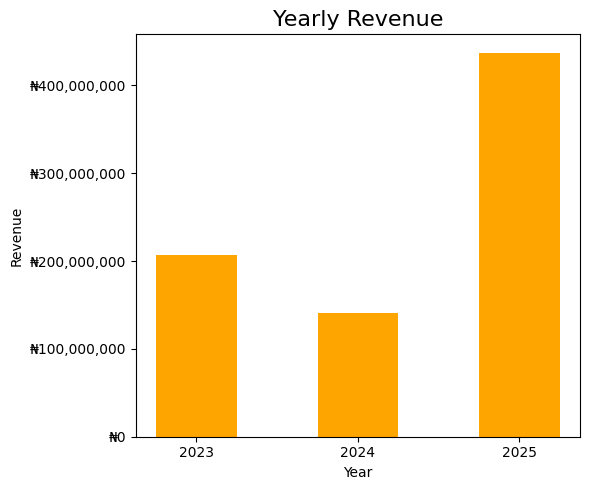

In [ ]:
#making a new column with just year the sale was made in
df['year'] = df['sale_date'].dt.year
total_revenue = df['total_sale'].sum()
print(f'the total revenue over the {df['year'].nunique()} year period comprised in total {total_revenue:,.2f} Naira')

#calculate the revenue by year
revenues_by_year = df.groupby('year')['total_sale'].sum()
print(revenues_by_year)

#formatting the revenue numbers due to many 0s in the amounts in Naira
def format_naira(x, pos):
  return f'₦{x:,.0f}'

#making a barchart with the revenue information
years = df['year'].unique()
plt.figure(figsize = (6,5))
plt.bar(years,revenues_by_year, color = 'orange', width = 0.5)
plt.title('Yearly Revenue',fontsize = 16)
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_naira))
plt.xticks(years, [int(y) for y in years])
plt.tight_layout()

###3.2 Regional Revenue

best performing state in revenue: Rivers with 71889881.04₦ in revenue generated
best performing state in sales: Benue with 500 units sold


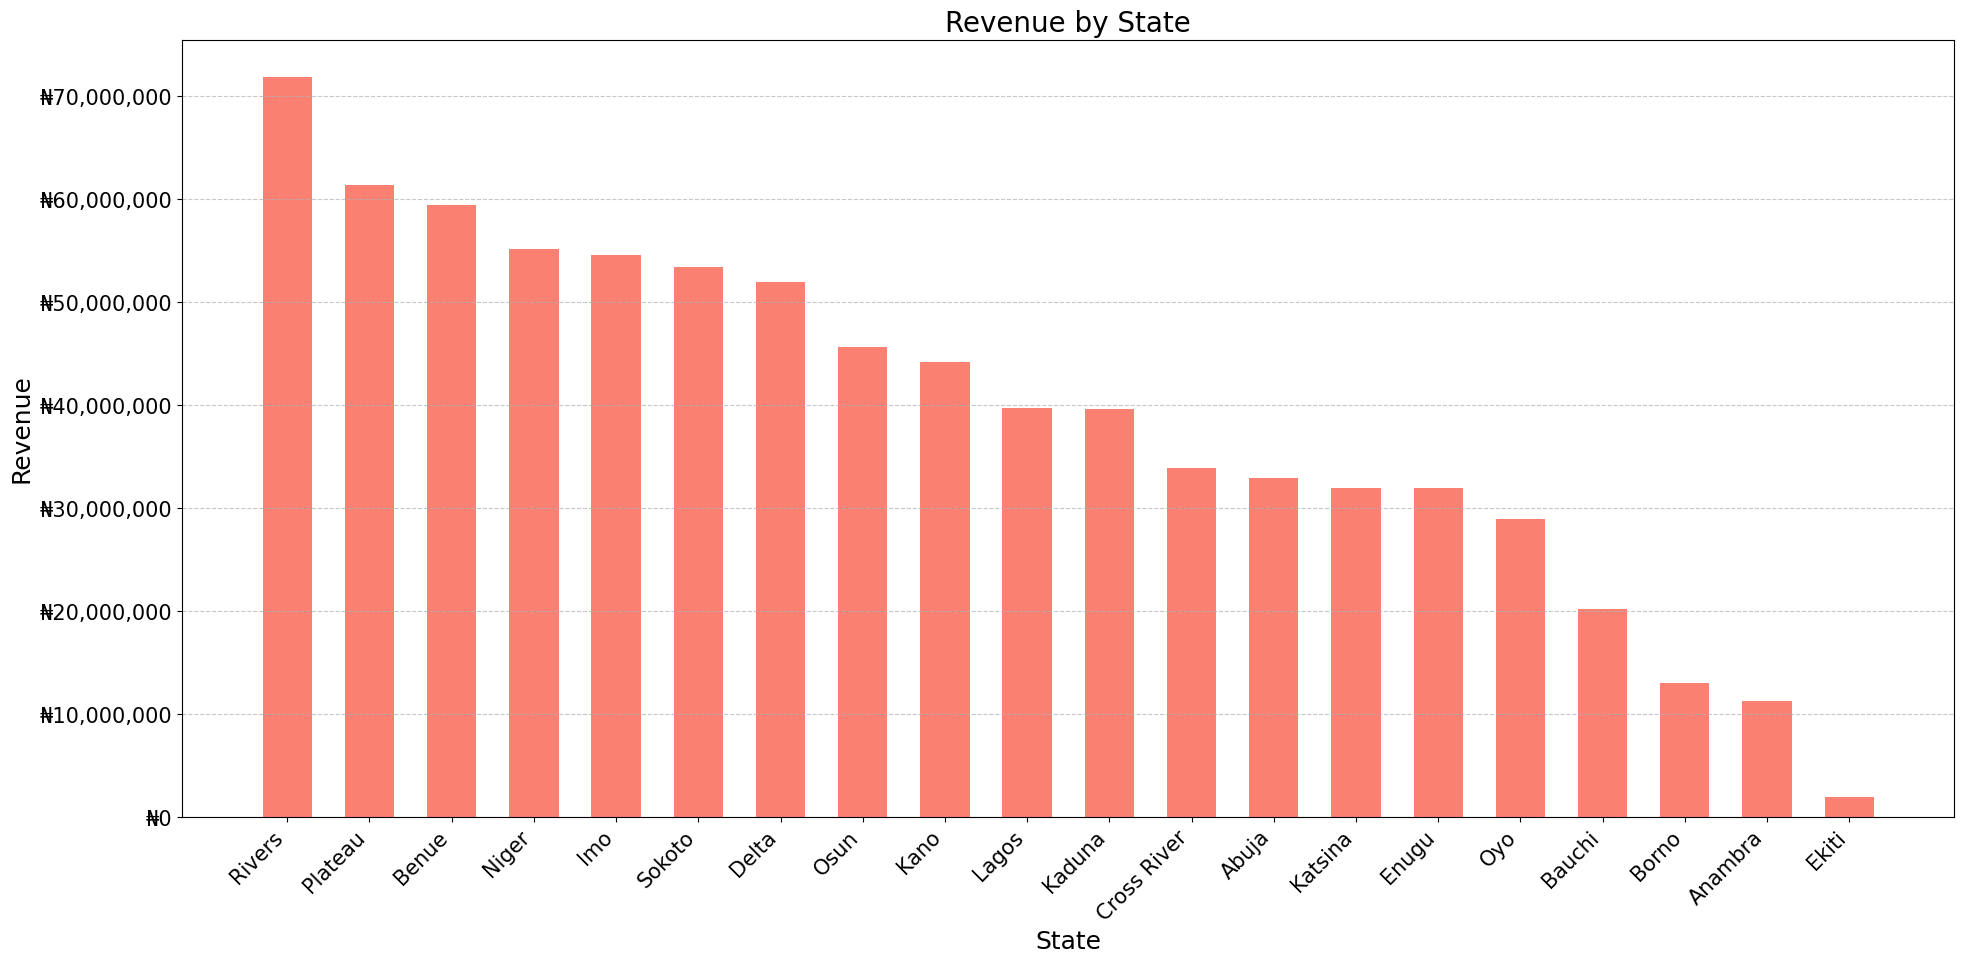

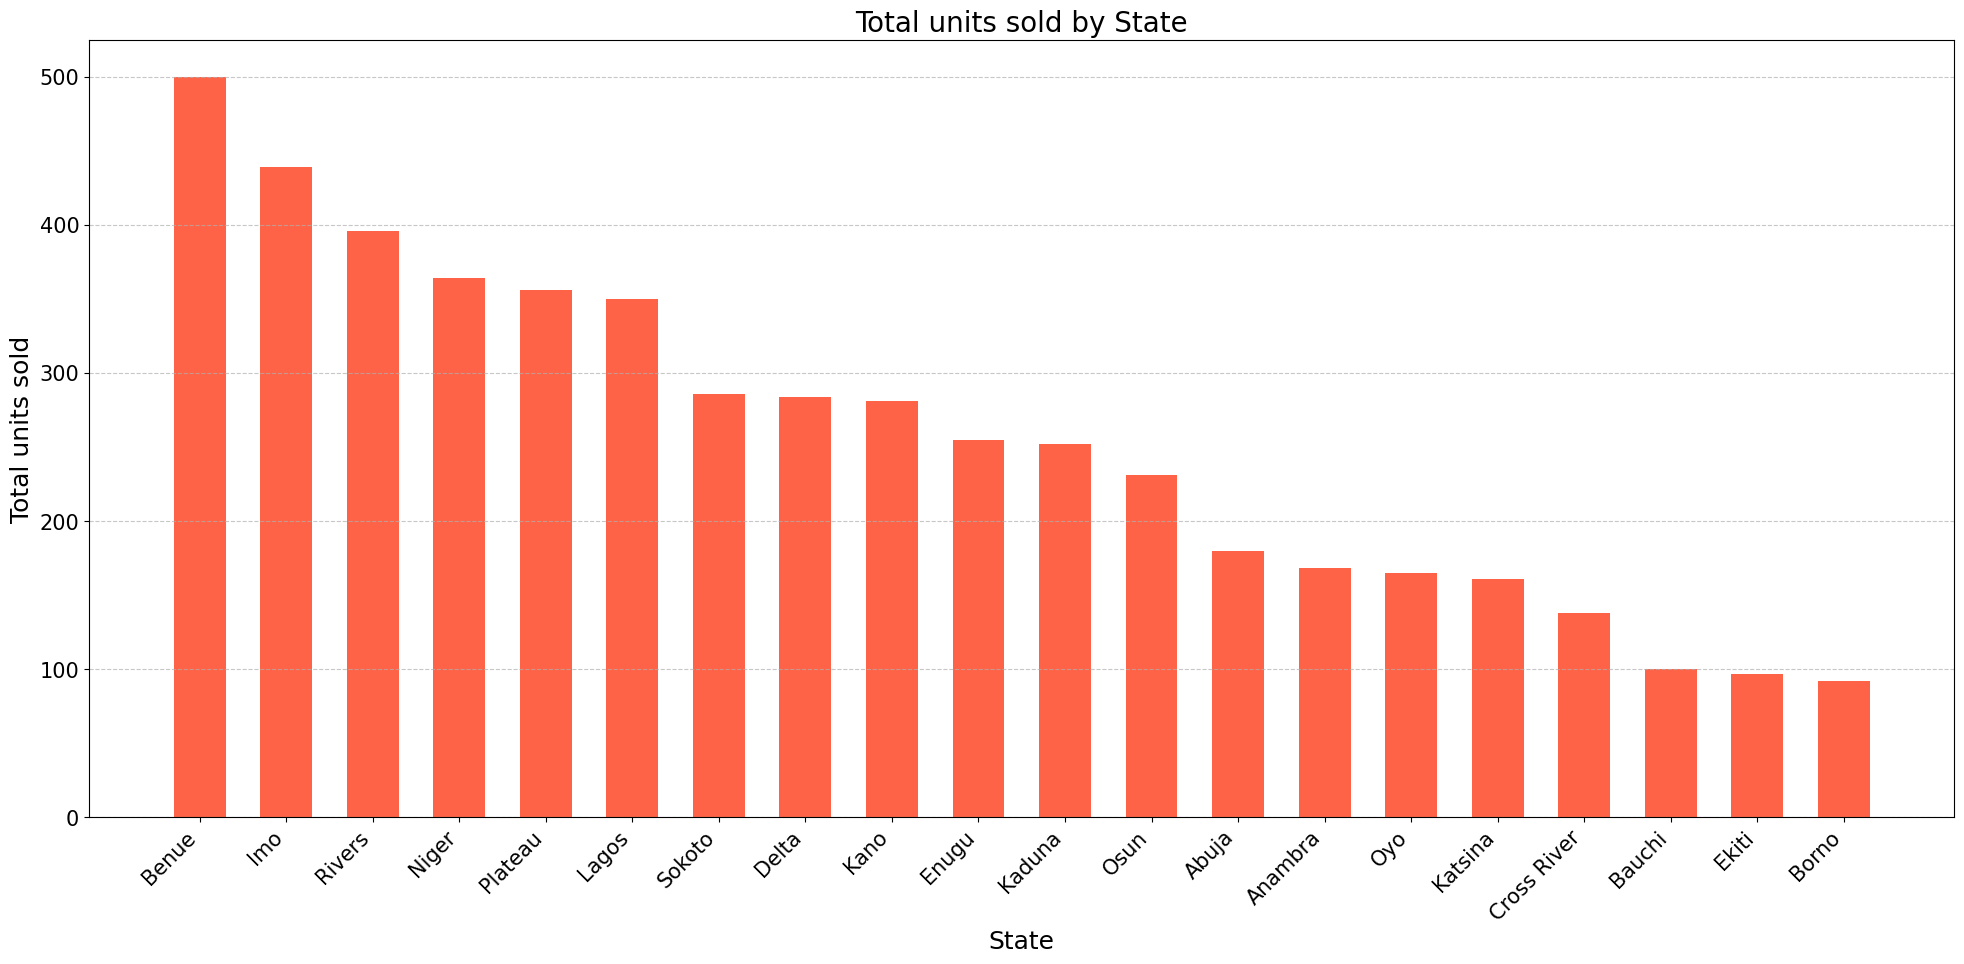

In [ ]:
#calculate the revenue and the total units sold by state
revenues_by_state = df.groupby('state')['total_sale'].sum().sort_values(ascending = False)
tunits_by_state = df.groupby('state')['units_sold'].sum().sort_values(ascending = False)

print(f'best performing state in revenue: {revenues_by_state.index[0]} with {revenues_by_state.iloc[0]}₦ in revenue generated')
print(f'best performing state in sales: {tunits_by_state.index[0]} with {int(tunits_by_state.iloc[0])} units sold')

#making a barchart with the revenue information
plt.figure(figsize = (20,10))
plt.bar(revenues_by_state.index, revenues_by_state, color = 'salmon', width = 0.6)
plt.title('Revenue by State', fontsize = 20)
plt.xlabel('State', fontsize = 18)
plt.ylabel('Revenue', fontsize = 18)
plt.xticks(rotation=45, ha="right", fontsize = 15)
plt.yticks(fontsize = 15)
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_naira))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(pad=2.0)

#making a barchart with the total units sold information
plt.figure(figsize = (20,10))
plt.bar(tunits_by_state.index, tunits_by_state, color = 'tomato', width = 0.6)
plt.title('Total units sold by State', fontsize = 20)
plt.xlabel('State', fontsize = 18)
plt.ylabel('Total units sold', fontsize = 18)
plt.xticks(rotation=45, ha="right", fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(pad=2.0)

####The data shows that the best performing state in terms of sales is different from the one bringing most revenue. This means that greater quantity of units sold doesn't necessarily mean higher revenue for the company.

###3.3 Products sold the most

          state     product  units_sold
4         Abuja       Phone       101.0
6       Anambra    Keyboard        96.0
7        Bauchi    Keyboard        56.0
12        Benue  Headphones       142.0
19        Borno     Monitor        41.0
20  Cross River     Monitor       138.0
22        Delta       Phone       187.0
25        Ekiti      Laptop        63.0
29        Enugu    Keyboard        74.0
35          Imo  Headphones       260.0
38       Kaduna     Charger        83.0
42         Kano    Keyboard       112.0
46      Katsina  Headphones        78.0
50        Lagos     Charger       116.0
58        Niger      Tablet       158.0
61         Osun    Keyboard        87.0
63          Oyo     Monitor        96.0
70      Plateau      Tablet        91.0
72       Rivers     Charger       134.0
78       Sokoto    Keyboard       152.0


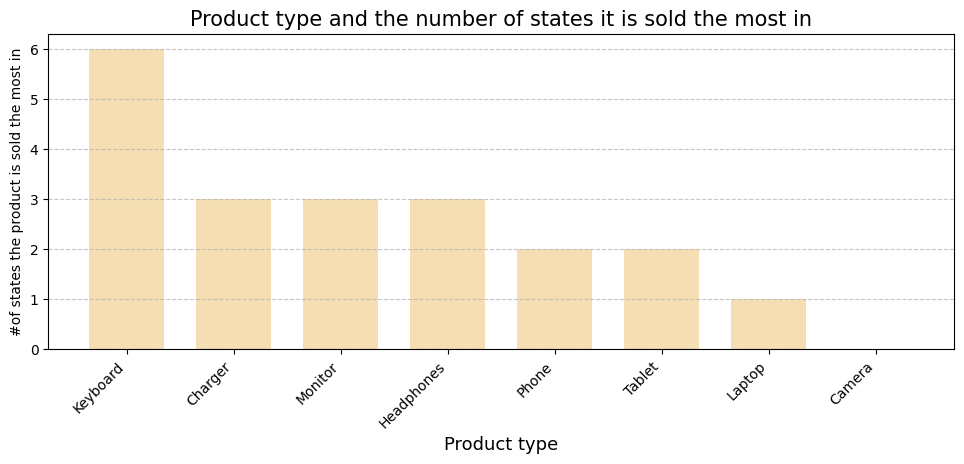

In [ ]:
#get the most sold product in each state
mostsold_by_state = df.groupby(['state','product'])['units_sold'].sum().reset_index()
mostsold_by_state = mostsold_by_state.loc[mostsold_by_state.groupby('state')['units_sold'].idxmax()]
print(mostsold_by_state[['state', 'product', 'units_sold']].sort_values('state').to_string())

#get the product type and how many states it's sold the most in
product_n_states = mostsold_by_state['product'].value_counts().reindex(df['product'].unique(), fill_value=0).sort_values(ascending=False)

#plot bar chart with product types and the number of states it's most sold in
plt.figure(figsize = (10,5))
plt.bar(product_n_states.index, product_n_states, color = "wheat", width = 0.7)
plt.title('Product type and the number of states it is sold the most in', fontsize = 15)
plt.xlabel('Product type', fontsize = 13)
plt.ylabel('#of states the product is sold the most in')
plt.xticks(rotation=45, ha="right", fontsize = 10)
plt.yticks(fontsize = 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(pad=2.0)

####Keyboard is the best selling product in 6 out of 20 states, making it the most consistently dominant product regionally. Camera leads in no state, indicating low demand nationwide. Inventory allocation should reflect these regional preferences.

###3.4 Most sold product nationally

the product that was sold the most nationally is Keyboard with overall 1076 units sold


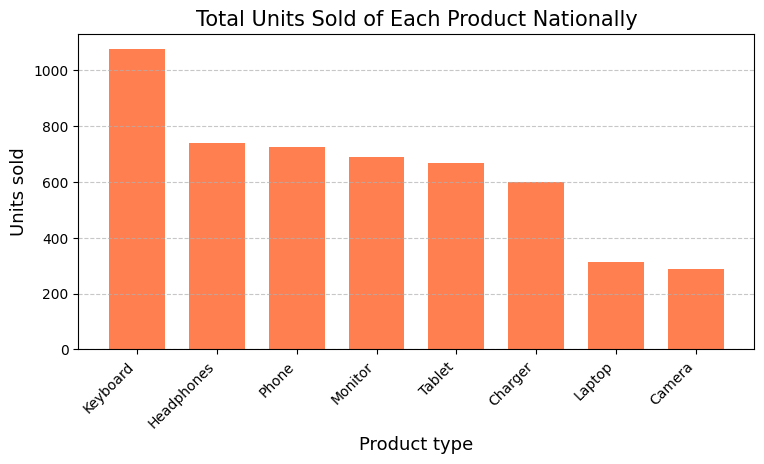

In [ ]:
#calculate the product with most sales
product_sales = df.groupby('product')['units_sold'].sum().sort_values(ascending = False)
print(f'the product that was sold the most nationally is {product_sales.index[0]} with overall {int(product_sales.iloc[0])} units sold')

#plot a bar chart with total units sold of each product type nationally
plt.figure(figsize = (8,5))
plt.bar(product_sales.index, product_sales, color = 'coral', width = 0.7)
plt.title("Total Units Sold of Each Product Nationally", fontsize = 15)
plt.xlabel('Product type', fontsize = 13)
plt.ylabel('Units sold', fontsize = 13)
plt.xticks(rotation=45, ha="right", fontsize = 10)
plt.yticks(fontsize = 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(pad=2.0)

####Keyboard is the most sold product nationally with 1,076 units sold. Laptop and Camera have the lowest volumes, likely due to their higher price points. High sales volume does not necessarily mean higher revenue — further analysis combining price data would be needed to determine which product generates the most revenue.

###3.5 Relationship between unit price and units sold

r-value:-0.0261


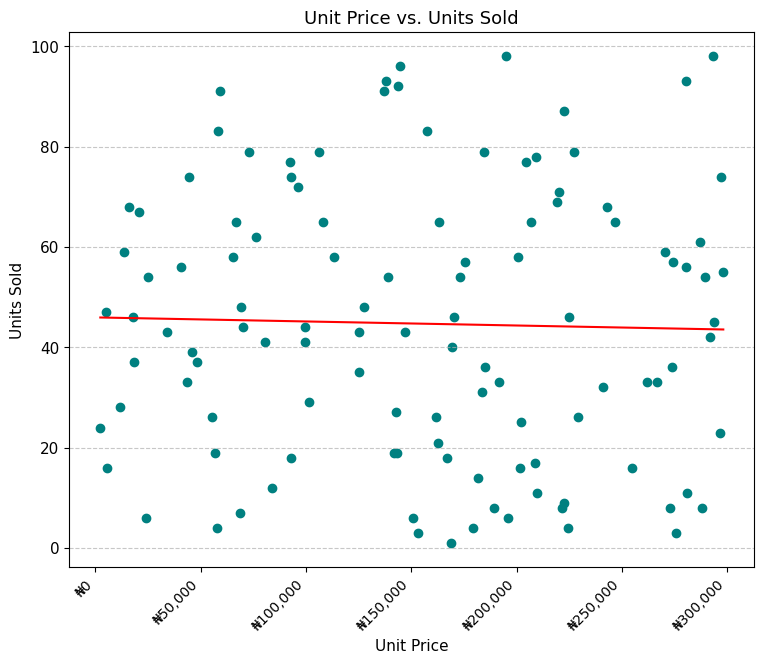

In [ ]:
#calculate correlation coefficient
r_value = df['unit_price'].corr(df['units_sold'])
print(f'r-value:{r_value:.4f}')

#plot the scatter graph
# calculate trend line
z = np.polyfit(df['unit_price'], df['units_sold'], 1)
p = np.poly1d(z)
plt.figure(figsize=(8,7))
plt.scatter(df['unit_price'], df['units_sold'], color = 'teal')
plt.title('Unit Price vs. Units Sold', fontsize = 13)
plt.xlabel('Unit Price', fontsize = 11)
plt.ylabel('Units Sold', fontsize = 11)
plt.xticks(rotation=45, ha="right", fontsize = 10)
plt.yticks(fontsize = 11)
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_naira))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.plot(sorted(df['unit_price']), p(sorted(df['unit_price'])), color='red')
plt.tight_layout(pad=2.0)

####As the r-value is -0.0261, there is virtually no correlation between unit price and units sold. This suggests that price is not a key driver of purchasing behaviour, meaning adjusting prices to meet business needs is unlikely to significantly impact sales volumes.

###3.6 Most effective sales channel

sales_channel
Online       1657.0
Retail       1276.0
Wholesale    1115.0
Direct       1047.0
Name: units_sold, dtype: float64
sales_channel
Online       2.358032e+08
Retail       2.152257e+08
Wholesale    1.670845e+08
Direct       1.654913e+08
Name: total_sale, dtype: float64


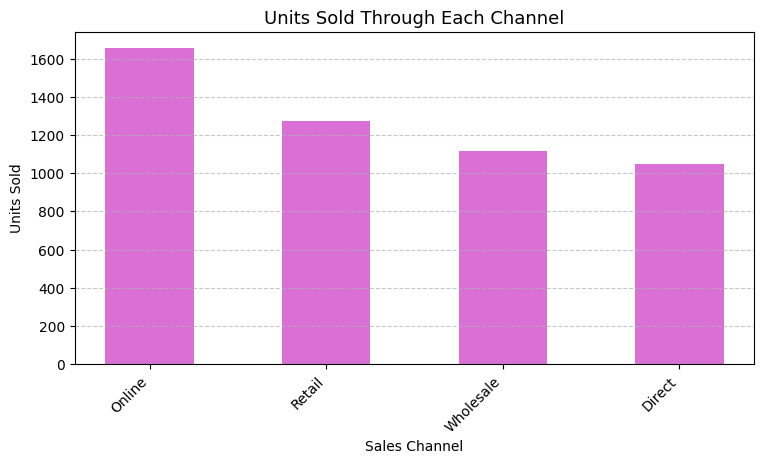

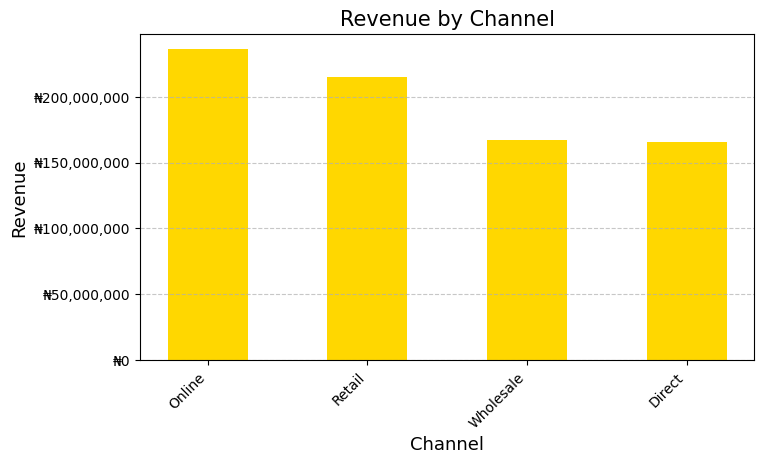

In [ ]:
#calculate sales and revenue per channel
sales_by_channel = df.groupby('sales_channel')['units_sold'].sum().sort_values(ascending = False)
revenue_by_channel = df.groupby('sales_channel')['total_sale'].sum().sort_values(ascending = False)

#display data with exact numbers (units sold)
print(sales_by_channel)
#plot bar chart with units sold by channel
plt.figure(figsize = (8,5))
plt.bar(sales_by_channel.index, sales_by_channel, color = 'orchid', width = 0.5)
plt.title('Units Sold Through Each Channel', fontsize = 13)
plt.xlabel('Sales Channel', fontsize = 10)
plt.ylabel('Units Sold', fontsize = 10)
plt.xticks(rotation=45, ha="right", fontsize = 10)
plt.yticks(fontsize = 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(pad=2.0)

#display data with exact numbers (units sold)
print(revenue_by_channel)
#plot bar chart with revenue generated by each channel
plt.figure(figsize = (8,5))
plt.bar(revenue_by_channel.index, revenue_by_channel, color = 'gold', width = 0.5)
plt.title('Revenue by Channel', fontsize = 15)
plt.xlabel('Channel', fontsize = 13)
plt.ylabel('Revenue', fontsize = 13)
plt.xticks(rotation=45, ha="right", fontsize = 10)
plt.yticks(fontsize = 10)
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_naira))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(pad=2.0)

As seen from analysis, the channels that result in most sales also result in most revenue generated for the company.